In [1]:
pwd

'c:\\Project\\THFORCASTING\\experiments'

In [2]:
import os
os.chdir('..')

## RAW DATA PROCESSING AND MERGING

In [3]:
import pandas as pd
import numpy as np

In [4]:
indices_path='RAW_DATA\indices data.csv'
indices_df = pd.read_csv(indices_path)

surface_path = 'RAW_DATA\surface_data.csv'
surface_df = pd.read_csv(surface_path)

In [5]:
indices_df.head()

,YEAR,MONTH,DAY,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS
0,1981,1,1,91.2,12.4,13.4,-1.4,3.0,21.7,24.7,284.41,993.98,0.0,0.0,22.8,5636
1,1981,1,1,66.0,9.3,8.0,0.0,6.2,22.7,28.9,281.75,856.09,0.0,0.0,24.7,5671
2,1981,1,2,75.7,10.2,11.3,1.6,10.2,20.1,30.3,282.11,956.13,0.0,0.0,20.4,5592
3,1981,1,2,111.7,8.5,7.5,0.8,13.1,20.1,33.2,280.44,836.26,0.0,0.0,23.0,5660
4,1981,1,3,64.0,2.1,-0.2,2.8,13.4,24.1,37.5,284.25,862.29,-260.5,0.8,19.7,5636


In [6]:
surface_df.head()

,YEAR,MONTH,DAY,TH
0,1981,1,1,0
1,1981,1,2,0
2,1981,1,3,0
3,1981,1,4,0
4,1981,1,5,0


In [7]:
indices_df.describe()

,YEAR,MONTH,DAY,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS
count,22449.000000,22449.000000,22449.000000,22448.000000,22449.000000,22449.000000,22449.000000,22449.000000,22449.000000,22449.000000,22449.000000,22449.000000,22449.000000,22449.000000,22449.000000,22449.000000
mean,1997.369415,6.545860,15.721190,185.977704,6.230157,-0.217252,23.384516,15.649601,24.432336,40.081937,291.947004,919.352828,-110.072529,1071.280877,40.479852,5756.678516
std,10.818510,3.430744,8.816237,93.530997,4.442731,6.544439,15.416031,7.246817,3.999584,9.213935,6.558205,60.890513,571.750166,1541.942522,17.206154,72.166469
min,1981.000000,1.000000,1.000000,5.800000,-10.800000,-21.700000,-62.300000,-49.700000,8.400000,-26.100000,254.750000,494.380000,-37319.000000,0.000000,-24.400000,2955.000000
25%,1989.000000,4.000000,8.000000,106.800000,3.400000,-4.600000,11.900000,12.100000,21.900000,35.600000,287.050000,885.790000,-121.400000,0.000000,25.400000,5707.000000
50%,1996.000000,7.000000,16.000000,189.200000,6.200000,-1.700000,28.000000,17.700000,23.900000,41.800000,294.000000,933.310000,-29.600000,170.400000,38.900000,5764.000000
75%,2004.000000,10.000000,23.000000,251.500000,8.800000,3.400000,35.700000,20.700000,26.900000,45.800000,297.330000,967.030000,0.000000,1795.700000,54.900000,5812.000000
max,2020.000000,12.000000,31.000000,850.700000,44.100000,27.800000,62.100000,33.500000,40.700000,69.800000,310.810000,1168.110000,73.000000,16555.900000,98.900000,5978.000000


In [8]:
surface_df.describe()

,YEAR,MONTH,DAY
count,14397.000000,14397.000000,14397.000000
mean,2000.326179,6.517052,15.727026
std,11.426269,3.452945,8.800485
min,1981.000000,1.000000,1.000000
25%,1990.000000,4.000000,8.000000
50%,2000.000000,7.000000,16.000000
75%,2010.000000,10.000000,23.000000
max,2020.000000,12.000000,31.000000


In [9]:
surface_df.TH.value_counts()

TH
0    11624
1     2772
         1
Name: count, dtype: int64

convert all dats columns into date time format

In [10]:
column_to_merge= ['YEAR','MONTH','DAY']

surface_df['Date'] = pd.to_datetime(surface_df[column_to_merge]).dt.strftime('%d/%m/%Y')

indices_df['Date'] = pd.to_datetime(indices_df[column_to_merge]).dt.strftime('%d/%m/%Y')

In [11]:
surface_df

,YEAR,MONTH,DAY,TH,Date
0,1981,1,1,0,01/01/1981
1,1981,1,2,0,02/01/1981
2,1981,1,3,0,03/01/1981
3,1981,1,4,0,04/01/1981
4,1981,1,5,0,05/01/1981
...,...,...,...,...,...
14392,2020,12,27,0,27/12/2020
14393,2020,12,28,0,28/12/2020
14394,2020,12,29,0,29/12/2020
14395,2020,12,30,0,30/12/2020


In [12]:
# drop them now

surface_df.drop(column_to_merge,inplace=True,axis=1)
indices_df.drop(column_to_merge,inplace=True,axis=1)

In [13]:
merged_df=pd.merge(surface_df,indices_df,on= 'Date',how = 'inner')

# save it

merged_df.to_csv('merged_df_all12.csv',index=False)

In [14]:
merged_df.head(10)

,TH,Date,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS
0,0,01/01/1981,91.2,12.4,13.4,-1.4,3.0,21.7,24.7,284.41,993.98,0.0,0.0,22.8,5636
1,0,01/01/1981,66.0,9.3,8.0,0.0,6.2,22.7,28.9,281.75,856.09,0.0,0.0,24.7,5671
2,0,02/01/1981,75.7,10.2,11.3,1.6,10.2,20.1,30.3,282.11,956.13,0.0,0.0,20.4,5592
3,0,02/01/1981,111.7,8.5,7.5,0.8,13.1,20.1,33.2,280.44,836.26,0.0,0.0,23.0,5660
4,0,03/01/1981,64.0,2.1,-0.2,2.8,13.4,24.1,37.5,284.25,862.29,-260.5,0.8,19.7,5636
5,0,04/01/1981,128.3,6.9,6.9,17.5,16.3,25.3,41.6,284.79,978.71,0.0,0.0,23.8,5581
6,0,04/01/1981,NaN,1.9,0.3,11.2,15.5,28.3,43.8,281.81,830.76,0.0,0.0,19.3,5625
7,0,05/01/1981,194.2,2.8,1.2,23.5,22.5,28.1,50.6,286.68,965.77,-138.5,83.1,28.6,5578
8,0,05/01/1981,157.8,-0.1,-3.2,31.3,20.1,27.3,47.4,286.87,875.90,-237.5,728.3,30.8,5599
9,0,06/01/1981,151.4,5.1,1.8,25.4,18.9,24.9,43.8,289.11,975.72,-112.9,47.9,33.2,5648


## Combining data
import merged data

In [15]:
import pandas as pd

merged_df = pd.read_csv("merged_df_all12.csv")

merged_df.head()

,TH,Date,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS
0,0,01/01/1981,91.2,12.4,13.4,-1.4,3.0,21.7,24.7,284.41,993.98,0.0,0.0,22.8,5636
1,0,01/01/1981,66.0,9.3,8.0,0.0,6.2,22.7,28.9,281.75,856.09,0.0,0.0,24.7,5671
2,0,02/01/1981,75.7,10.2,11.3,1.6,10.2,20.1,30.3,282.11,956.13,0.0,0.0,20.4,5592
3,0,02/01/1981,111.7,8.5,7.5,0.8,13.1,20.1,33.2,280.44,836.26,0.0,0.0,23.0,5660
4,0,03/01/1981,64.0,2.1,-0.2,2.8,13.4,24.1,37.5,284.25,862.29,-260.5,0.8,19.7,5636


In [16]:
merged_df.TH.value_counts()

TH
0    17715
1     4337
Name: count, dtype: int64

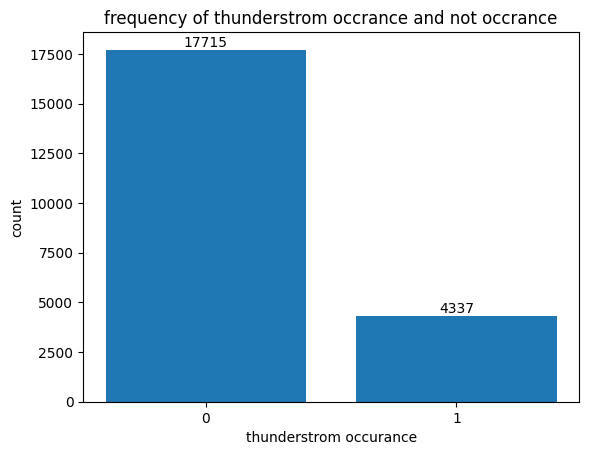

In [17]:
import matplotlib.pyplot as plt 

th_count = merged_df.TH.value_counts()

plt.bar(th_count.index, th_count.values)

plt.xlabel('thunderstrom occurance')

plt.ylabel("count")

plt.title("frequency of thunderstrom occrance and not occrance")

plt.xticks([0,1], ['0','1'])

for i , count in enumerate(th_count.values):
    plt.text(i,count, str(count), ha = 'center',va = 'bottom')

plt.show()

In [18]:
# Combine variables and create new features
merged_df['Environmental_Stability'] = merged_df['Showalter index'] + merged_df['LIFTED index']
merged_df['Moisture_Indices'] = merged_df['PRECIPITABLE WATER']
merged_df['Convective_Potential'] = merged_df['CAPE'] + merged_df['CINE']
merged_df['Temperature_Pressure'] = merged_df['1000-500 THICKNESS']
merged_df['Moisture_Temperature_Profiles'] = merged_df['PLCL']

# Drop the original variables
merged_df.drop(['Showalter index', 'LIFTED index', 'PRECIPITABLE WATER', 'Cross totals index', 'Vertical totals index', 'CAPE', 'CINE', '1000-500 THICKNESS', 'TLCL', 'PLCL'], axis=1, inplace=True)




## 🔹 Why We Are Doing This

There are four main reasons:

### 1️⃣ Reduce Dimensionality

Instead of using many correlated variables, we combine them into fewer, stronger features.

### 2️⃣ Reduce Multicollinearity

Many atmospheric indices measure similar properties (instability, moisture, etc.). Combining them reduces redundancy and correlation between predictors.

### 3️⃣ Improve Model Performance

Models often perform better when features represent broader physical concepts rather than fragmented measurements.

### 4️⃣ Improve Interpretability

Instead of many technical meteorological variables, we group them into meaningful categories like:

* Stability
* Moisture
* Convective potential

---

## 🔹 Explanation of Each New Feature

### 1️⃣ Environmental_Stability

**Terms:**

* **Showalter Index** → Measures thunderstorm potential
* **Lifted Index (LI)** → Measures atmospheric instability

Both measure atmospheric instability.
👉 Combining them provides a stronger overall instability indicator.

**Advantages:**

* Reduces redundancy
* Captures instability in one feature
* Improves storm prediction modeling

---

### 2️⃣ Moisture_Indices

**Term:**

* **Precipitable Water** → Total moisture in the atmospheric column

**Advantages:**

* Moisture is critical for rainfall
* Creates a clean moisture-related feature

---

### 3️⃣ Convective_Potential

**Terms:**

* **CAPE (Convective Available Potential Energy)** → Energy available for storm development
* **CINE (Convective Inhibition Energy)** → Energy suppressing storm formation

Together, they describe storm formation dynamics.

**Advantages:**

* Captures both driving and resisting forces of convection
* Better representation of thunderstorm development

---

### 4️⃣ Temperature_Pressure

**Term:**

* **1000–500 mb Thickness** → Indicates average temperature of an air column

Higher thickness = warmer air mass.

**Advantages:**

* Represents atmospheric thermal structure
* Important for severe weather prediction

---

### 5️⃣ Moisture_Temperature_Profiles

**Term:**

* **PLCL (Pressure Level of Condensation Level)** → Height where air becomes saturated

**Advantages:**

* Indicates cloud base height
* Influences storm intensity

---

## 🔹 Why Drop Original Variables?

```python
merged_df.drop([...], axis=1, inplace=True)
```

**Reasons:**

1. Prevent duplication
2. Reduce noise
3. Avoid overfitting
4. Simplify the dataset
5. Improve computational efficiency

If the original variables were kept, the model would:

* See repeated information
* Potentially produce unstable coefficients
* Be more prone to overfitting

---

## 🔹 Big Picture

You are transforming:

> Raw meteorological measurements
> → Into physically meaningful atmospheric indicators
> → For better machine learning modeling



In [19]:
merged_df

,TH,Date,SWEAT index,K index,Totals totals index,Environmental_Stability,Moisture_Indices,Convective_Potential,Temperature_Pressure,Moisture_Temperature_Profiles
0,0,01/01/1981,91.2,-1.4,24.7,25.8,22.8,0.0,5636,993.98
1,0,01/01/1981,66.0,0.0,28.9,17.3,24.7,0.0,5671,856.09
2,0,02/01/1981,75.7,1.6,30.3,21.5,20.4,0.0,5592,956.13
3,0,02/01/1981,111.7,0.8,33.2,16.0,23.0,0.0,5660,836.26
4,0,03/01/1981,64.0,2.8,37.5,1.9,19.7,-259.7,5636,862.29
...,...,...,...,...,...,...,...,...,...,...
22047,0,29/12/2020,133.6,-22.8,28.1,23.7,14.0,0.0,5727,818.86
22048,0,30/12/2020,135.8,-6.5,29.5,25.6,16.2,0.0,5715,892.90
22049,0,30/12/2020,127.0,-4.5,29.7,36.9,16.1,0.0,5733,673.52
22050,0,31/12/2020,97.0,-4.2,22.5,50.0,13.9,0.0,5720,698.99


In [20]:
# Get the column names
columns = list(merged_df.columns)

# Remove the 'TH' column from the list
columns.remove('TH')

# Append the 'TH' column at the end of the list
columns.append('TH')

# Reorder the columns in the DataFrame
merged_df = merged_df[columns]


In [21]:
merged_df.drop(['Date'], axis=1 ,inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_15396\160721053.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df.drop(['Date'], axis=1 ,inplace=True)


In [22]:
merged_df.to_csv('merged_df_all12k_combined.csv', index=False)

In [23]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE # to handle imbalanced data
from sklearn.model_selection import train_test_split # 80 / 20
from sklearn.ensemble import RandomForestClassifier   # model to train
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix





In [24]:
merged_df.head()

,SWEAT index,K index,Totals totals index,Environmental_Stability,Moisture_Indices,Convective_Potential,Temperature_Pressure,Moisture_Temperature_Profiles,TH
0,91.2,-1.4,24.7,25.8,22.8,0.0,5636,993.98,0
1,66.0,0.0,28.9,17.3,24.7,0.0,5671,856.09,0
2,75.7,1.6,30.3,21.5,20.4,0.0,5592,956.13,0
3,111.7,0.8,33.2,16.0,23.0,0.0,5660,836.26,0
4,64.0,2.8,37.5,1.9,19.7,-259.7,5636,862.29,0


In [25]:
merged_df.dropna(inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_15396\41306911.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df.dropna(inplace=True)


In [26]:
X = merged_df.iloc[:,:-1]
y = merged_df.iloc[:,-1]

In [27]:
X.isna().sum()

SWEAT index                      0
K index                          0
Totals totals index              0
Environmental_Stability          0
Moisture_Indices                 0
Convective_Potential             0
Temperature_Pressure             0
Moisture_Temperature_Profiles    0
dtype: int64

In [28]:
merged_df[X.isna().any(axis=1)]

,SWEAT index,K index,Totals totals index,Environmental_Stability,Moisture_Indices,Convective_Potential,Temperature_Pressure,Moisture_Temperature_Profiles,TH


In [29]:
# merged_df[merged_df['SWEAT index'].isna()]

Resampling using smote

In [30]:
# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [31]:



# model = RandomForestClassifier() 

# model.fit(X_train,y_train)

# print(model)

# y_pred = model.predict(X_test)



In [32]:
# y_pred

In [33]:
# model

Evaluate now

In [34]:

# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)
# cm = confusion_matrix(y_test, y_pred)
# cm




In [35]:
# from sklearn.metrics import ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
# plt.show()

POD → Did we catch the event?

FAR → Did we raise unnecessary alarms?

CSI → Overall event prediction quality

HSS → Is model better than random?

In [36]:

# # Calculate additional performance metrics
# total_positives = cm[1].sum()
# total_negatives = cm[0].sum()
# true_positives = cm[1][1]
# false_positives = cm[0][1]
# false_negatives = cm[1][0]
# true_negatives = cm[0][0]

# ## assignment 2  - doc provided 

# pod = true_positives / total_positives  # Probability of Detection
# far = false_positives / total_negatives  # False Alarm Rate
# hss = 2 * ((true_positives * true_negatives) - (false_positives * false_negatives)) / (
#         (true_positives + false_negatives) * (false_positives + true_negatives) +
#         (true_positives + false_positives) * (false_negatives + true_negatives))  # Heidke Skill Score
# csi = true_positives / (true_positives + false_positives + false_negatives)  # Critical Success Index


# # Print the evaluation metrics and additional performance metrics
# print("Accuracy:", accuracy)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1-score:", f1)
# print("="*40)
# print("Probability of Detection (POD):", pod)
# print("False Alarm Rate (FAR):", far)
# print("Heidke Skill Score (HSS):", hss)
# print("Critical Success Index (CSI):", csi)


In [37]:
import pandas as pd
import joblib
import mlflow
import mlflow.sklearn

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [38]:
X = merged_df[['SWEAT index','K index','Totals totals index',
               'Environmental_Stability','Moisture_Indices',
               'Convective_Potential','Temperature_Pressure',
               'Moisture_Temperature_Profiles']]

y = merged_df['TH']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [39]:
def evaluate_model(model):
    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "pod": tp/(tp+fn) if (tp+fn) else 0,
        "far": fp/(fp+tn) if (fp+tn) else 0,
        "csi": tp/(tp+fp+fn) if (tp+fp+fn) else 0
    }

    hss_den = ((tp+fn)*(fn+tn)+(tp+fp)*(fp+tn))
    metrics["hss"] = 2*((tp*tn)-(fp*fn))/hss_den if hss_den else 0

    return metrics

In [40]:
models = {
    "Logistic": LogisticRegression(max_iter=2000),
    "SVM": SVC(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [41]:
def linear_pipeline(model):
    return Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

def tree_pipeline(model):
    return Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

In [47]:
param_grids = {

    "Logistic": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2"]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale"]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"]
    },

    "DecisionTree": {
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5]
    },

    "RandomForest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10],
        "model__min_samples_split": [2, 5]
    },

    "GradientBoosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.1]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [3, 6]
    },
    "NaiveBayes": {
    "model__var_smoothing": [1e-9, 1e-8, 1e-7]
}
}

In [43]:
import os
import mlflow

# 1️⃣ Ensure folder exists
os.makedirs("mlruns", exist_ok=True)

# 2️⃣ Set tracking explicitly
mlflow.set_tracking_uri("file:./mlruns")

# 3️⃣ Set experiment
mlflow.set_experiment("Thunderstorm_Prediction_ML")

c:\Project\THFORCASTING\thenv\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:177: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/01 17:47:08 INFO mlflow.tracking.fluent: Experiment with name 'Thunderstorm_Prediction_ML' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Project/THFORCASTING/mlruns/320984272582818390', creation_time=1772367428133, experiment_id='320984272582818390', last_update_time=1772367428133, lifecycle_stage='active', name='Thunderstorm_Prediction_ML', tags={}>

In [50]:
from sklearn.model_selection import GridSearchCV

tuned_results = {}

for name, model in models.items():

    with mlflow.start_run(run_name=name):

        # Select correct pipeline
        if name in ["Logistic", "SVM", "KNN"]:
            pipe = linear_pipeline(model)
        else:
            pipe = tree_pipeline(model)

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grids[name],
            cv=5,
            scoring="f1",
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        metrics = evaluate_model(best_model)

        # 🔥 Log only what matters
        mlflow.log_params(grid.best_params_)
        mlflow.log_metrics({
            "test_f1": metrics["f1_score"],
            "test_recall": metrics["recall"],
            "test_precision": metrics["precision"],
            "test_accuracy": metrics["accuracy"]
        })

        mlflow.sklearn.log_model(best_model, artifact_path=name)
        tuned_results[name] = {
         "best_params": grid.best_params_,
          "metrics": metrics,
           "model": best_model
}

2026/03/01 20:13:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 20:13:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/01 20:17:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 20:17:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/01 20:17:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 20:17:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/01 20:19:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 20:19:07 WARNING mlflow.utils.

In [51]:
import joblib

best_model_name = max(
    tuned_results,
    key=lambda m: tuned_results[m]["metrics"]["f1_score"]
)

best_model = tuned_results[best_model_name]["model"]

joblib.dump(best_model, f"{best_model_name}_best_model.pkl")

print("Best Model:", best_model_name)
print("Model saved successfully!")

Best Model: RandomForest
Model saved successfully!
